# Basic Multi Layer Perceptron using Iris Dataset


## a. Lab requirements

The second lab assignment is to use scikit-learn to implement a neural network for the Iris dataset, which is available on the Moodle page.

1. Construct a neural network consisting of:

    • an input layer with 4 nodes

    • at least one hidden layer (with, say, 20 nodes)

    • an output layer with 3 nodes. You may add more hidden layers if you wish, but at least one is required.

2. Prepare the Iris dataset by:

    (a) normalising the input values using max-min normalisation.

    (b) creating a one-hot encoding of the target values.

3. Split the dataset into training, validation, and test sets.

4. Train the neural network on the prepared Iris dataset. Use the sum-of-squares loss
function.

5. During training, after every epoch, print:

    • the sum-of-squares loss on the training set.

6. After training, print the accuracy on the test set.

## b. Imports

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor 
from sklearn.metrics import accuracy_score

## c. Load Data

In [2]:
#load data locally
cols = ["x1", "x2", "x3", "x4", "target"]
df = pd.read_csv("Iris.csv", sep=";", header=None, names=cols)
df.head()

,x1,x2,x3,x4,target
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## d. Data Cleaning

In [3]:
#Checking the data profile
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      150 non-null    float64
 1   x2      150 non-null    float64
 2   x3      150 non-null    float64
 3   x4      150 non-null    float64
 4   target  150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


### Key Takeaways:

1. We have no missing values in any of the columns.

2. The target column is of string type. Need conversion to integer before modeling; One hot encoding has been recommended in the requirements.



In [4]:
#check for duplicates
total_duplicates = df.duplicated().sum()
print(int(total_duplicates))

3


We have three duplicates in our dataset.

In [5]:
df[df.duplicated()]

,x1,x2,x3,x4,target
34,4.9,3.1,1.5,0.1,Iris-setosa
37,4.9,3.1,1.5,0.1,Iris-setosa
142,5.8,2.7,5.1,1.9,Iris-virginica


In [6]:
#dropt the duplicates
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 147 entries, 0 to 149
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      147 non-null    float64
 1   x2      147 non-null    float64
 2   x3      147 non-null    float64
 3   x4      147 non-null    float64
 4   target  147 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.9 KB


I dropped all the duplicates keepiing the first occurances only. This reduced or dataset to 147 from 150 values.

In [5]:
#Checking the summary stats
df.describe()

,x1,x2,x3,x4
count,147.000000,147.000000,147.000000,147.000000
mean,5.856463,3.055782,3.780272,1.208844
std,0.829100,0.437009,1.759111,0.757874
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
df.groupby(["target"])["target"].count()

target
Iris-setosa        48
Iris-versicolor    50
Iris-virginica     49
Name: target, dtype: int64

The target column is pretty much balanced.

## e. Split the Raw Data

In [ ]:
#Split to features and target
X = df[["x1", "x2", "x3", "x4"]]
y= df["target"]


#split to train & validation  and test sets (80/20)   we are spliting the data to training&validation and test data
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42)

#split the training and validation sets (75/25) training&validation then split to training and validation
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, shuffle=True, random_state=42)

I split the dataset before scaling to avoid data leakage.

## f. Data Preprocessing

### Feature Scaling and Normalization

In [ ]:
#Istatnitate the scaler
scaler = MinMaxScaler()

# Fit only on training data, transform all other three sets
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val) 
X_test_scaled = scaler.transform(X_test)

### One hot Encoding

In [ ]:
encoder = OneHotEncoder(sparse_output=False)

# Fit on training labels, transform all three
y_train_encoded = encoder.fit_transform(y_train.values.reshape(-1, 1)) 
y_val_encoded = encoder.transform(y_val.values.reshape(-1, 1))
y_test_encoded = encoder.transform(y_test.values.reshape(-1, 1))

## g. Modeling

### Building the Multilayer Neural Network

In [ ]:
model = MLPRegressor(
    hidden_layer_sizes=(30, 50, 30),
    max_iter=1,
    solver="lbfgs",
    warm_start=True,
    random_state=42
)

train_losses = []
val_losses = []

for epoch in range(100):

    model.fit(X_train_scaled, y_train_encoded)

    # Predict on training data to compute SSE
    y_train_pred = model.predict(X_train_scaled)

    # SSE training loss
    train_sse = np.sum((y_train_encoded - y_train_pred) ** 2)

    # Predict continuous outputs
    y_val_pred = model.predict(X_val_scaled)

    # SSE validation loss
    val_loss = np.sum((y_val_encoded - y_val_pred) ** 2)

    # Convert back to class labels
    pred_classes = np.argmax(y_val_pred, axis=1)  #0 and 1 instead of 0.3, 0.4, 0.7;   1 0 0 , 0 1 0, 0 0 1
    true_classes = np.argmax(y_val_encoded, axis=1)  

    accuracy = np.mean(pred_classes == true_classes)

    #store train and validation losses for plotting
    train_losses.append(train_sse)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1:3d} | "
        f"Train SSE: {train_sse:.4f} | "
        f"Val SSE: {val_loss:.4f} | "
        f"Acc: {accuracy:.4f}"
    )

c:\Users\Window\Desktop\COMS5026A\Labs\.venv-1\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\Users\Window\Desktop\COMS5026A\Labs\.venv-1\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.ma

Epoch   1 | Train SSE: 70.1677 | Val SSE: 24.0595 | Acc: 0.3667
Epoch   2 | Train SSE: 60.2937 | Val SSE: 20.8040 | Acc: 0.3333
Epoch   3 | Train SSE: 54.5568 | Val SSE: 18.7534 | Acc: 0.6667
Epoch   4 | Train SSE: 52.1463 | Val SSE: 17.8346 | Acc: 0.6667
Epoch   5 | Train SSE: 49.8989 | Val SSE: 17.0146 | Acc: 0.6667
Epoch   6 | Train SSE: 47.2453 | Val SSE: 16.1315 | Acc: 0.6667
Epoch   7 | Train SSE: 46.1155 | Val SSE: 15.6572 | Acc: 0.6333
Epoch   8 | Train SSE: 43.6578 | Val SSE: 14.8408 | Acc: 0.6333
Epoch   9 | Train SSE: 42.1255 | Val SSE: 14.2751 | Acc: 0.7000
Epoch  10 | Train SSE: 40.6857 | Val SSE: 13.7638 | Acc: 0.7333
Epoch  11 | Train SSE: 38.8928 | Val SSE: 13.1858 | Acc: 0.7667
Epoch  12 | Train SSE: 37.8188 | Val SSE: 12.6839 | Acc: 0.7000
Epoch  13 | Train SSE: 36.5617 | Val SSE: 12.4023 | Acc: 0.8000
Epoch  14 | Train SSE: 35.7605 | Val SSE: 11.9357 | Acc: 0.7333
Epoch  15 | Train SSE: 34.5778 | Val SSE: 11.7392 | Acc: 0.9000
Epoch  16 | Train SSE: 31.3795 | Val SSE

c:\Users\Window\Desktop\COMS5026A\Labs\.venv-1\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\Users\Window\Desktop\COMS5026A\Labs\.venv-1\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.ma

## h. Model Testing

In [25]:
#Testing the model
test_predictions = model.predict(X_test_scaled)
converted_test_preds = np.argmax(test_predictions, axis=1)
converted_y_test_encoded = np.argmax(y_test_encoded, axis=1)
test_acc = accuracy_score(converted_y_test_encoded, converted_test_preds)
print(f"Test Accuracy: {test_acc}")

Test Accuracy: 0.9333333333333333


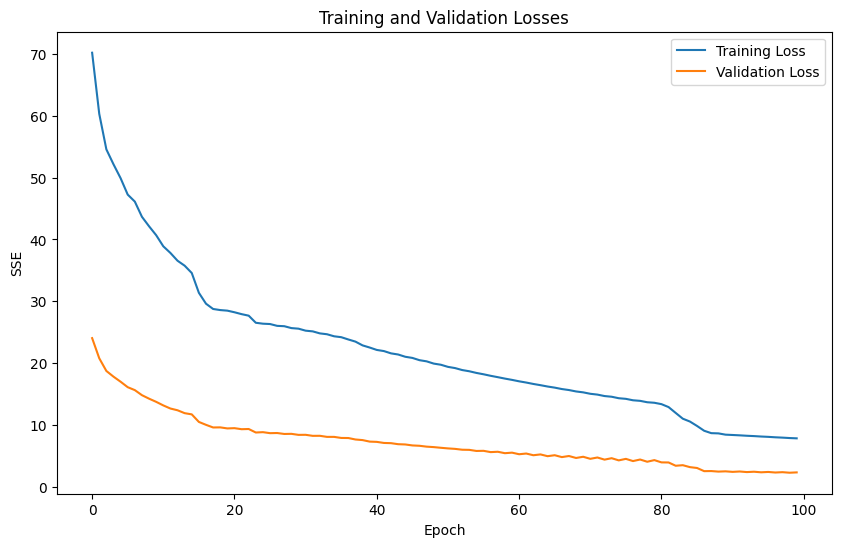

In [26]:
#plotting the training and validation losses
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('SSE')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()